# Weather Classification Technical Report
CPSC-322 Data Science | Fall 2025 | Written by Aiden Tabrah & Valon Haslem

### Introduction


#### 1) Overview:
[Weather Category Dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset) is a .csv file with 96.5k instances and 12 attributes. The attribute being selected for classification is the "summary" attribute, which weather predictors use to classify weather conditions in short descriptions.

#### 2) Description:
We will be using 10 non-classification attributes for training our classifiers, out of the 12. The layoyut of the dataset is as follows:  
  
**Summary**                     - Various classification labels such as "Partly Cloudy" or "Mostly Cloudy"   
 ___
**Date**                 - Dates from 2005 to 2016  
**Precip-type**               - rain, snow, or other   
**Temperature (C)**                 - Temperature in celsius from -21.8 to 39.9  
**Apparent Temperature (C)**                   -  How it "feels" outside due to wind or other conditions. Ranges from -27.7 to 39.3  
**Humidity**                      - Percentage between 0.00 and 1.00  
**Wind Speed (km/h)**           - Wind speed in kilometers per hour, from 0 to 63.9  
**Wind Bearing (degrees)**              - Wind direction from 0 to 359  
**Visibility (km)**                 - How far one should be able to see, in kilometers.  
**Pressure (millibars)**               - Pressure from 0 to 1.05k  
**Loud Cover** - Potentially cloud cover? All data values are 0.0 though. (Will not be used)  
**Daily Summary** - A more descriptive classification of the data, that isn't standardized and varies more often. (Will not be used)


#### 3) Findings:
TODO: [Insert summary of findings]

#### Imports

In [1]:
from tabulate import tabulate
import importlib

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.mypytable
importlib.reload(mysklearn.mypytable)
from mysklearn.mypytable import MyPyTable 

import mysklearn.myclassifiers
importlib.reload(mysklearn.myclassifiers)
from mysklearn.myclassifiers import MyDecisionTreeClassifier

import mysklearn.myevaluation
importlib.reload(mysklearn.myevaluation)
import mysklearn.myevaluation as myevaluation

# Constants:
k = 10
seed = 1

#### Data Cleaning / Setup

There were a couple attributes that needed cleaning, and we used these strategies for the following attribtues:
- Pressure - 0.0 pressure is not a legitimate value, and we replaced those invalid values with the mean pressure of the dataset.
- Missing values - any instance with a missing value is removed from the dataset.
- Date - needs to be turned into a continuous attribute rather than categorical for analysis with the rest of the attributes.
- Precip-type - This is a very strong predictor, so we should keep this.
- All attributes - all remaining attributes besides the classification are continuous. They should be normalized.

In [2]:

weather_data = MyPyTable().load_from_file("input-data/weatherHistory.csv")
weather_data.remove_rows_with_missing_values()
weather_data.save_to_file("output-data/weatherHistory_cleaned.csv")

weather_data.replace_column("Formatted Date", myutils.convert_date_to_numeric(weather_data.get_column("Formatted Date")))
weather_data.normalize_values(["Formatted Date", "Temperature (C)","Apparent Temperature (C)",
                               "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])

weather_data.save_to_file("output-data/weatherHistory_normalized_and_cleaned.csv")

#### Loading data

In [ ]:
weather_data = MyPyTable().load_from_file("output-data/weatherHistory_normalized_and_cleaned.csv")

all_ys = weather_data.select_columns(["Summary"]).data
weather_x_data = weather_data.select_columns(["Formatted Date", "Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])
all_xs = weather_x_data.data

[[1143842400.0, 'Partly Cloudy', 'rain', 9.472222222222221, 7.3888888888888875, 0.89, 14.1197, 251.0, 15.826300000000002, 0.0, 1015.13, 'Partly cloudy throughout the day.'], [1143846000.0, 'Partly Cloudy', 'rain', 9.355555555555558, 7.227777777777776, 0.86, 14.2646, 259.0, 15.826300000000002, 0.0, 1015.63, 'Partly cloudy throughout the day.'], [1143849600.0, 'Mostly Cloudy', 'rain', 9.377777777777778, 9.377777777777778, 0.89, 3.9284000000000003, 204.0, 14.9569, 0.0, 1015.94, 'Partly cloudy throughout the day.'], [1143853200.0, 'Partly Cloudy', 'rain', 8.28888888888889, 5.944444444444446, 0.83, 14.1036, 269.0, 15.826300000000002, 0.0, 1016.41, 'Partly cloudy throughout the day.'], [1143856800.0, 'Mostly Cloudy', 'rain', 8.755555555555553, 6.977777777777779, 0.83, 11.0446, 259.0, 15.826300000000002, 0.0, 1016.51, 'Partly cloudy throughout the day.'], [1143860400.0, 'Partly Cloudy', 'rain', 9.222222222222221, 7.11111111111111, 0.85, 13.9587, 258.0, 14.9569, 0.0, 1016.66, 'Partly cloudy th

#### Comparing Classifiers
Decision Tree - Need to discretize continuous classifiers for this to work.
Knn - should be very simple since everything is already normalized.
Naive Bayes - also need to do some discretizing.

Set of possible cols: {'Humid and Partly Cloudy', 'Breezy and Mostly Cloudy', 'Light Rain', 'Dry', 'Foggy', 'Windy and Mostly Cloudy', 'Breezy and Foggy', 'Partly Cloudy', 'Humid and Mostly Cloudy', 'Mostly Cloudy', 'Windy and Overcast', 'Windy and Foggy', 'Windy', 'Breezy', 'Humid and Overcast', 'Dry and Mostly Cloudy', 'Clear', 'Drizzle', 'Dangerously Windy and Partly Cloudy', 'Breezy and Dry', 'Overcast', 'Windy and Partly Cloudy', 'Dry and Partly Cloudy', 'Breezy and Partly Cloudy', 'Breezy and Overcast', 'Windy and Dry', 'Rain'}

In addition, histogram shows that some values are significantly more frequent than others, so we will have significant issues with data distributions.

Set of possible cols: {'Humid and Partly Cloudy', 'Breezy and Mostly Cloudy', 'Light Rain', 'Dry', 'Foggy', 'Windy and Mostly Cloudy', 'Breezy and Foggy', 'Partly Cloudy', 'Humid and Mostly Cloudy', 'Mostly Cloudy', 'Windy and Overcast', 'Windy and Foggy', 'Windy', 'Breezy', 'Humid and Overcast', 'Dry and Mostly Cloudy', 'Clear', 'Drizzle', 'Dangerously Windy and Partly Cloudy', 'Breezy and Dry', 'Overcast', 'Windy and Partly Cloudy', 'Dry and Partly Cloudy', 'Breezy and Partly Cloudy', 'Breezy and Overcast', 'Windy and Dry', 'Rain'}


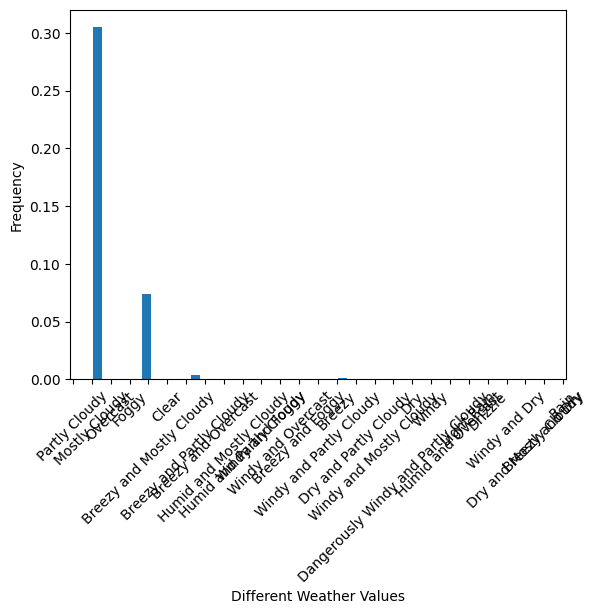

In [23]:
# dec_tree = MyDecisionTreeClassifier()
# # train test split
# X_train, X_test, y_train, y_test = myevaluation.train_test_split(X = all_xs, y = all_ys)
# dec_tree.fit(X_train=X_train, y_train=y_train)
# y_preds = dec_tree.predict(X_test= X_test)
# acc_score = myevaluation.accuracy_score(y_true=y_test, y_pred=y_preds)
# print(f'Accuracy Score is {acc_score}')
summary_col = weather_data.get_column('Summary')
import matplotlib.pyplot as plt
plt.figure()
print(f'Set of possible cols: {set(summary_col)}')
plt.hist(x = summary_col, density=True, rwidth = .2, histtype= 'barstacked')
plt.xlabel(xlabel= 'Different Weather Values')
plt.ylabel('Frequency')
plt.xticks(rotation = 45)
plt.show()